In [1]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False)

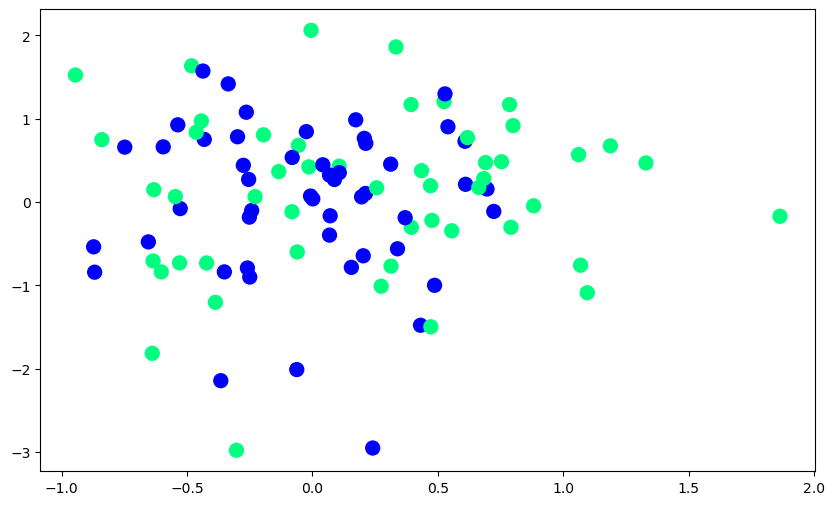

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [3]:
# Perceptron trick
def perceptron(X,y):

    X = np.insert(X, 0, 1, axis=1) # add bias term
    weights = np.ones(X.shape[1]) # initialize weights
    lr = 0.1 # learning rate

    for i in range(1000):
        j = np.random.randint(0,100) 
        y_hat = step(np.dot(X[j], weights)) # linear combination
        weights = weights + lr * (y[j] - y_hat) * X[j] # update weights

    return weights[0], weights[1:] # return bias and weights

In [4]:
def step(z):
    return 1 if z > 0 else 0

In [5]:
intercept_, coef_ = perceptron(X,y)

In [6]:
print(coef_)
print(intercept_)

[ 0.20564442 -0.08635772]
1.3877787807814457e-16


In [7]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [8]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

(-3.0, 2.0)

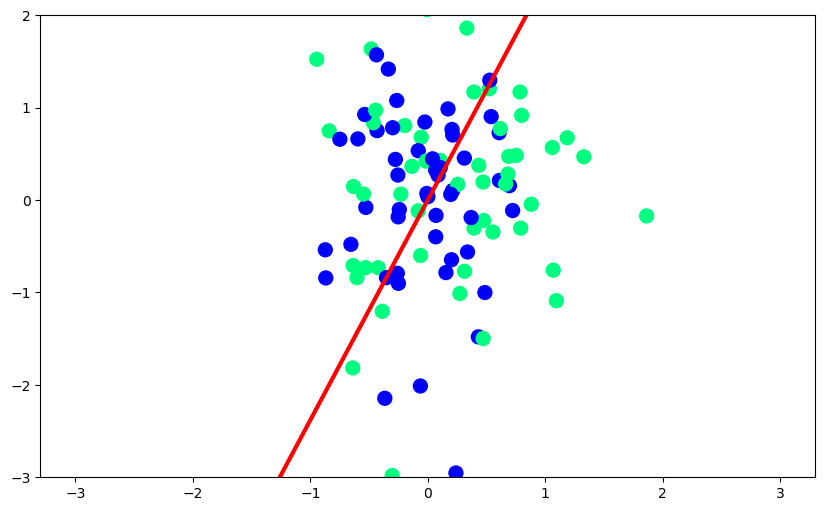

In [9]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)

In [10]:
def perceptron(X,y):
    
    m = []
    b = []

    X = np.insert(X, 0, 1, axis=1) # add bias term
    weights = np.ones(X.shape[1]) # initialize weights
    lr = 0.1 # learning rate

    for i in range(200):
        j = np.random.randint(0,100) 
        y_hat = step(np.dot(X[j], weights)) # linear combination
        weights = weights + lr * (y[j] - y_hat) * X[j] # update weights

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))


    return m, b

In [11]:
m, b = perceptron(X,y)

In [12]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = m[0] * x_i + b[0]
ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
